<a href="https://colab.research.google.com/github/titan-spyer/ML_Price_Prediction/blob/main/price_predictor_system/analysis/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Adding system path to perform the Operation
import sys
import os

# Define the path to the 'analysis' folder which contains 'analyze_src'
project_path = "/content/ML_Price_Prediction/price_predictor_system/analysis"

if project_path not in sys.path:
    sys.path.append(project_path)

In [2]:
#Imports
import pandas as pd
import numpy as np

from analyze_src.basic_data_inspection import DataInspectionContext, BasicDataTypesInspection, SummaryStatisticsInspection
from analyze_src.missing_value_analysis import SimpleMissingValueAnalysis
from analyze_src.univariate_analysis import UnivariateAnalyzer, NumericalAnalysis, CategoricalAnalysis
from analyze_src.bivariate_analysis import BivariateAnalyzer, NumericalVsNumericalAnalysis, CategoricalVsNumericalAnalysis
from analyze_src.multivariate_analysis import SimpleMultivariateAnalysis

#Setting the value for clear vision
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [3]:
# Load the data
data_path = "/content/ML_Price_Prediction/Data.zip"
df = pd.read_csv(data_path)

In [4]:
#Basic Data Inspection
data_inspector = DataInspectionContext(BasicDataTypesInspection())
data_inspector.execute_inspection(df)


--- Data Types Inspection ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-nul

In [5]:
#Switch Startegy to summary statistics
data_inspector.set_strategy(SummaryStatisticsInspection())
data_inspector.execute_inspection(df)


--- Summary Statistics(Numerical Feature) ---
            Order           PID  MS SubClass  Lot Frontage       Lot Area  \
count  2930.00000  2.930000e+03  2930.000000   2440.000000    2930.000000   
mean   1465.50000  7.144645e+08    57.387372     69.224590   10147.921843   
std     845.96247  1.887308e+08    42.638025     23.365335    7880.017759   
min       1.00000  5.263011e+08    20.000000     21.000000    1300.000000   
25%     733.25000  5.284770e+08    20.000000     58.000000    7440.250000   
50%    1465.50000  5.354536e+08    50.000000     68.000000    9436.500000   
75%    2197.75000  9.071811e+08    70.000000     80.000000   11555.250000   
max    2930.00000  1.007100e+09   190.000000    313.000000  215245.000000   

       Overall Qual  Overall Cond   Year Built  Year Remod/Add  Mas Vnr Area  \
count   2930.000000   2930.000000  2930.000000     2930.000000   2907.000000   
mean       6.094881      5.563140  1971.356314     1984.266553    101.896801   
std        1.411026


Missing Values Count by Column:
Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64

Visualizing Missing Values...


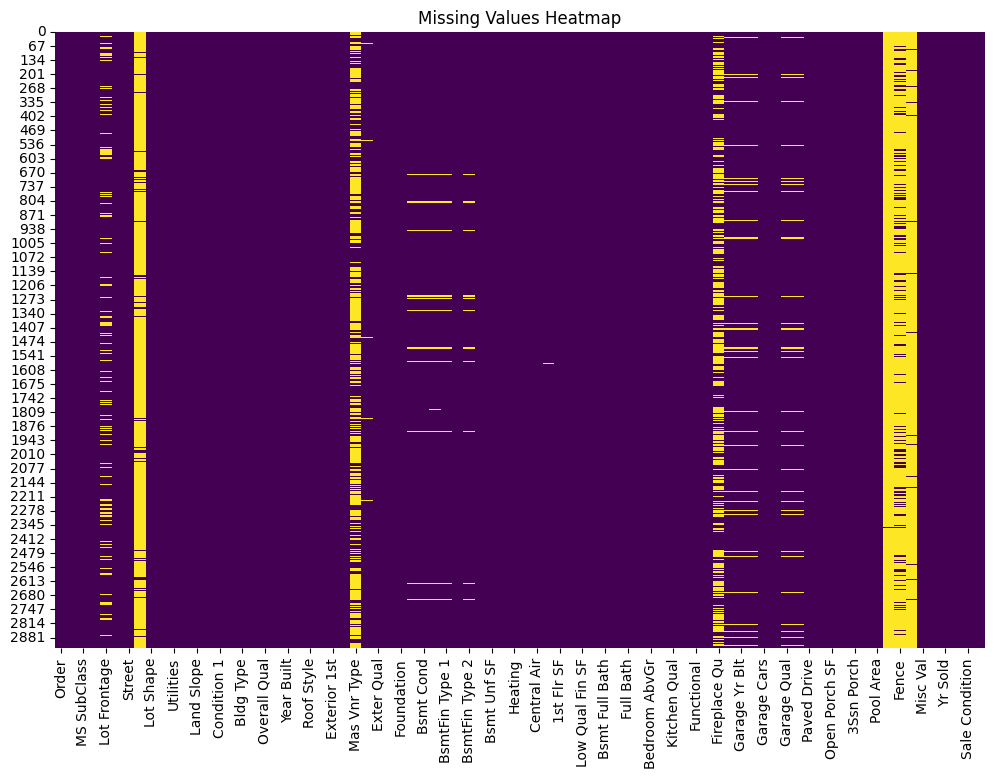

In [6]:
# Missing value analysis
missing_value_analysis = SimpleMissingValueAnalysis()
missing_value_analysis.analyze(df)

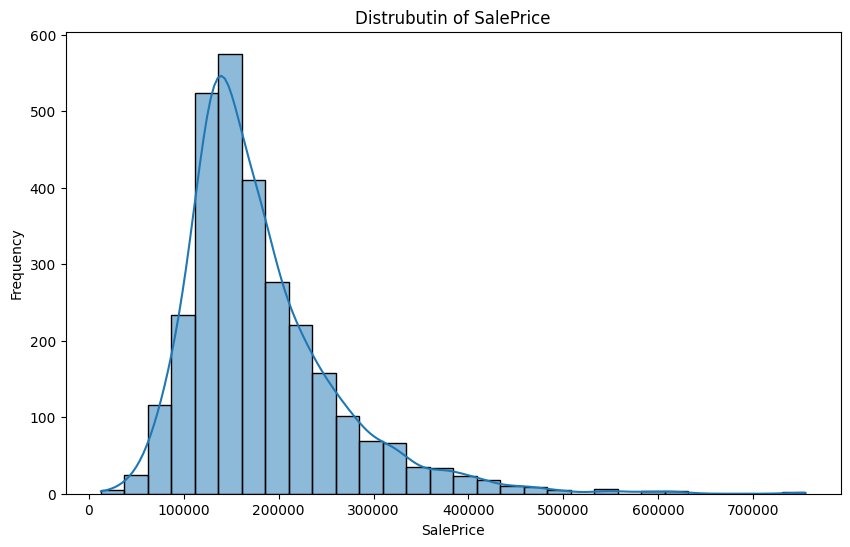

In [8]:
# Univariate analysis
# Analyzing Numerical feature
univariate_analyzer = UnivariateAnalyzer(NumericalAnalysis())
univariate_analyzer.execute_analysis(df, 'SalePrice')

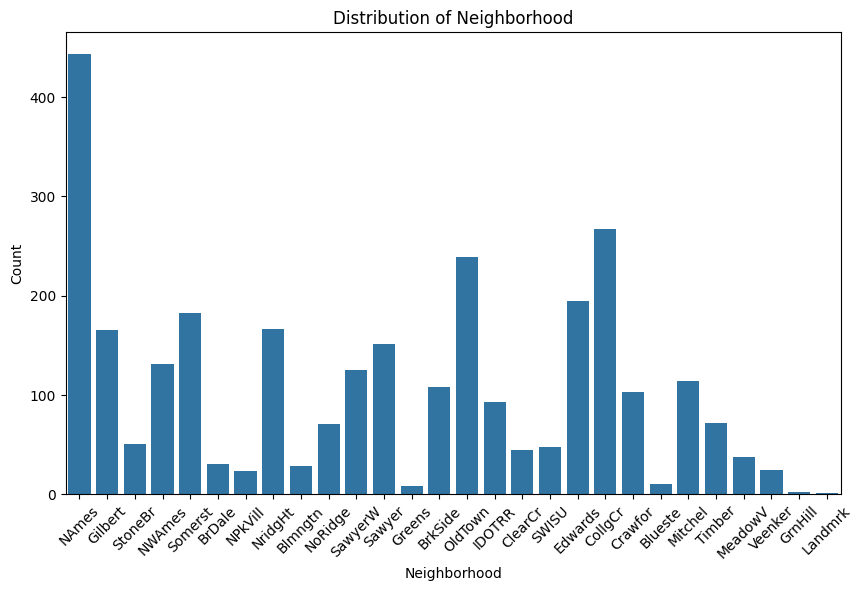

In [9]:
# Analyzing Categorical Feature
univariate_analyzer.set_strategy(CategoricalAnalysis())
univariate_analyzer.execute_analysis(df, 'Neighborhood')

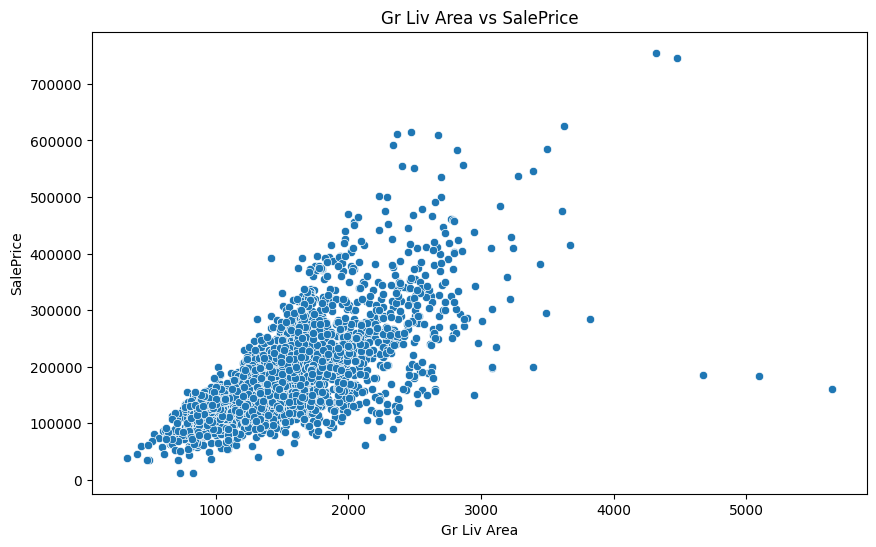

In [10]:
# Bivariate Anlysis
# Analyzing NumericalvsNumerical Feature
bivariate_analyzer = BivariateAnalyzer(NumericalVsNumericalAnalysis())
bivariate_analyzer.execute_analysis(df, 'Gr Liv Area', 'SalePrice')

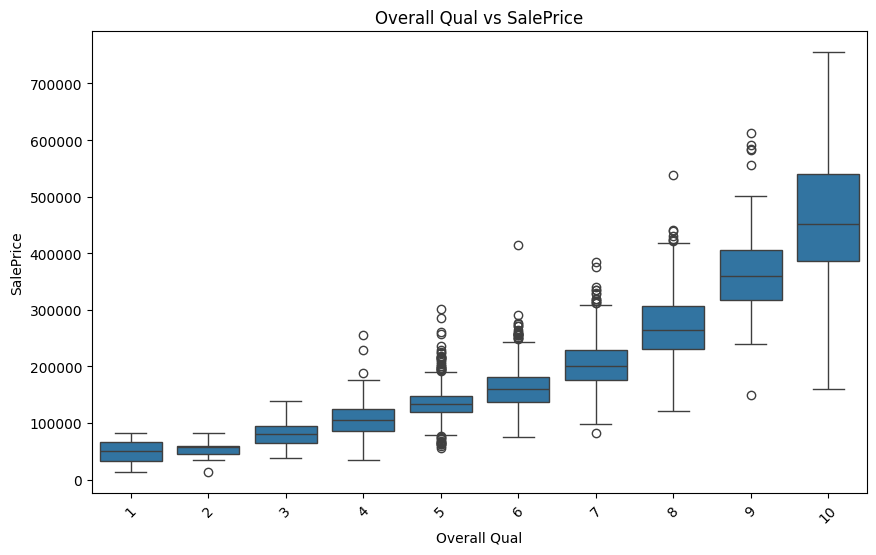

In [11]:
# Analyzing CategoricalvsNumerical Feature
bivariate_analyzer.set_strategy(CategoricalVsNumericalAnalysis())
bivariate_analyzer.execute_analysis(df, 'Overall Qual', 'SalePrice')

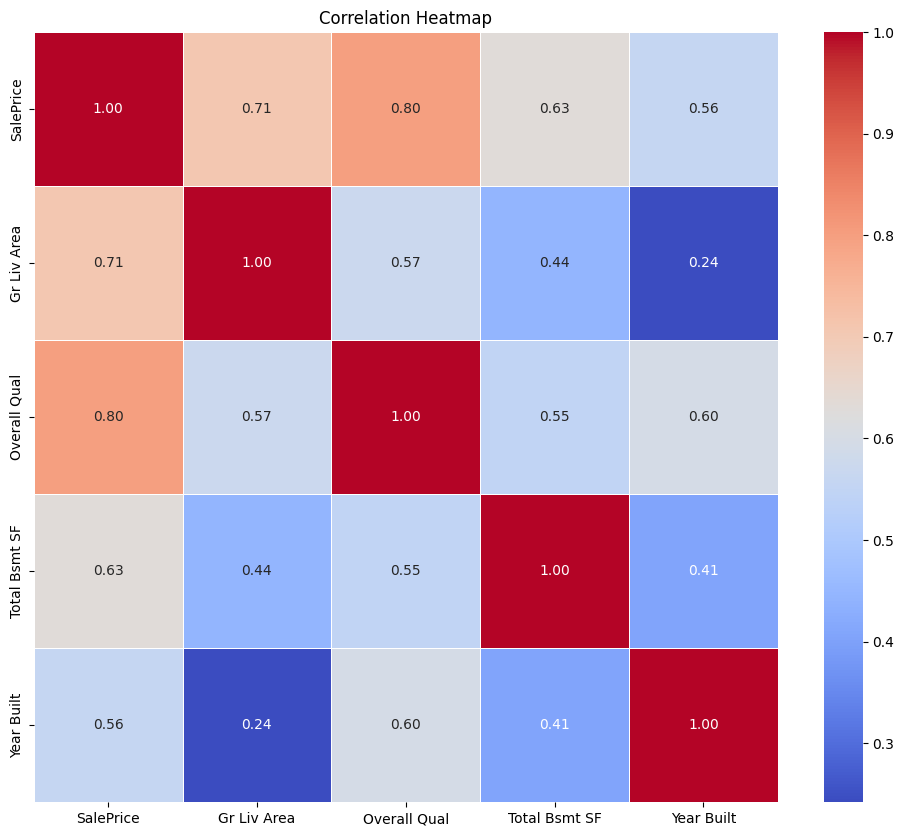

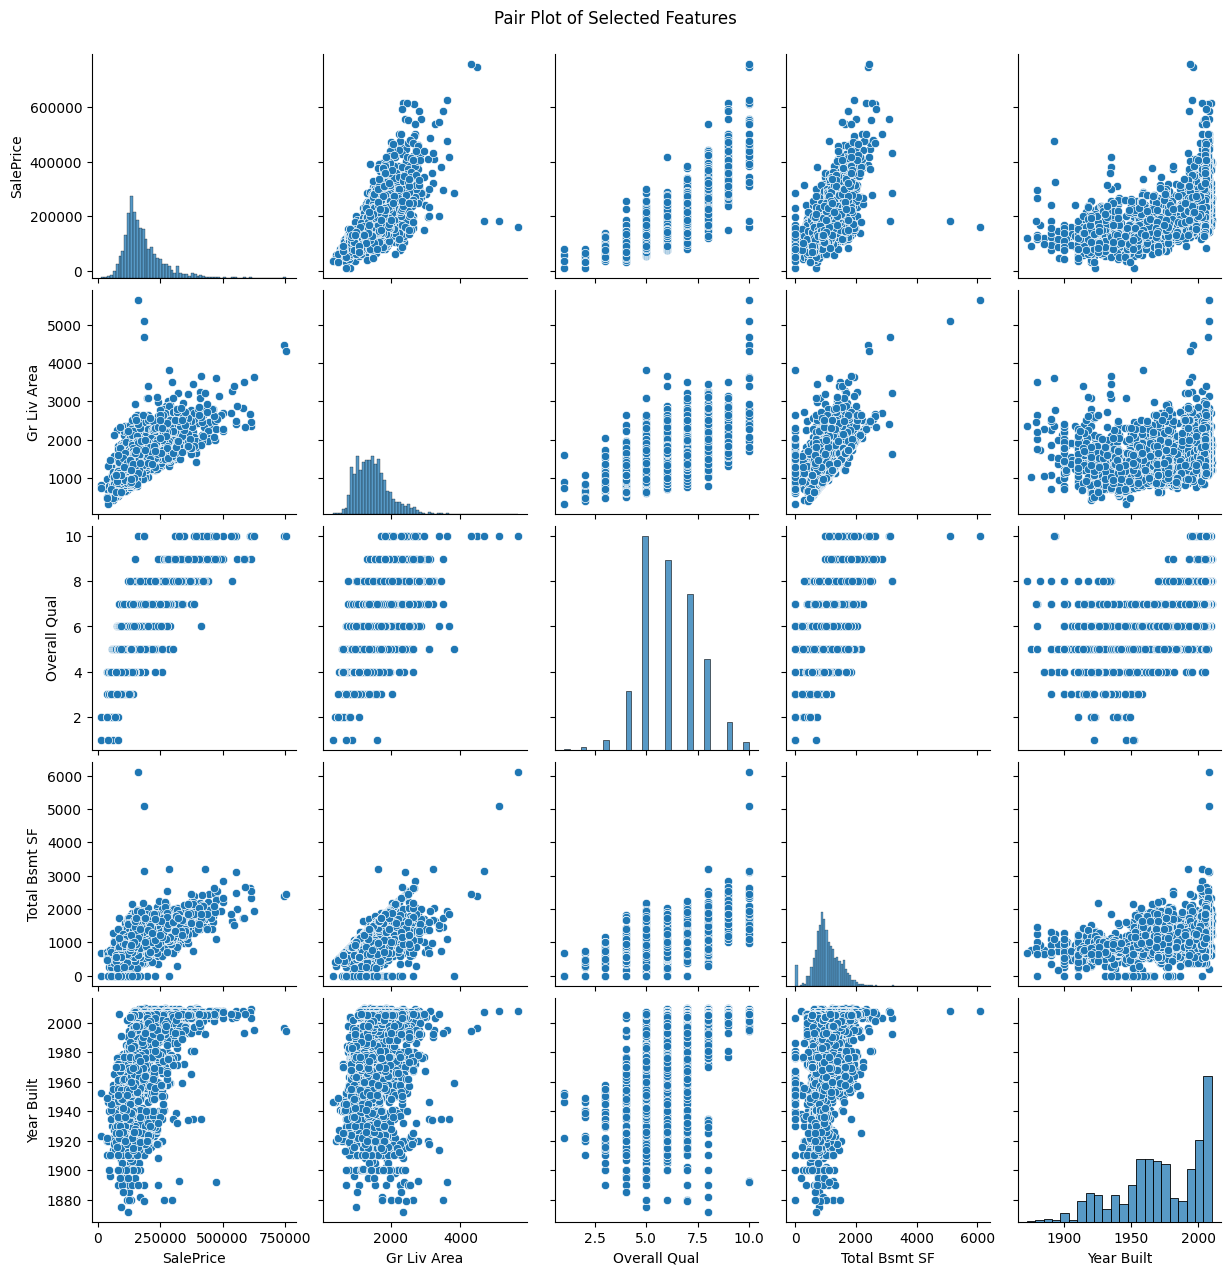

In [12]:
#Multivariate Analysis

#Initialising the analysis feature
multivariate_analyzer = SimpleMultivariateAnalysis()

# Providing features to be analyze
selected_features = df[['SalePrice', 'Gr Liv Area', 'Overall Qual', 'Total Bsmt SF', 'Year Built']]

#Performing analysis
multivariate_analyzer.analyze(selected_features)